# Probability Distributions: The Foundation of Machine Learning

**Why this matters:** Probability distributions are everywhere in AI/ML. Loss functions like cross-entropy are built on them. Variational Autoencoders (VAEs) learn to model data distributions. Reinforcement learning uses distributions to represent uncertainty. Yet they're rarely taught explicitly.

**What we'll learn:**
- The difference between discrete and continuous distributions
- How to work with PMFs (Probability Mass Functions) and PDFs (Probability Density Functions)
- Key distributions: Bernoulli, Categorical, Binomial, Uniform, and Gaussian
- Mean, variance, and sampling from distributions
- Visual intuitions for how distributions behave
- Where these show up in machine learning

By the end, you'll have deep intuitions about probability distributions and recognize them throughout your ML journey.

## 1. Setup

Let's import the libraries we'll need for this exploration.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from aiml_notebooks import set_seed

%load_ext autoreload
%autoreload 2

Set random seed for reproducibility.

In [2]:
set_seed(42)

## 2. Probability: The Basics

### What is Probability?

**Probability** measures how likely an event is to occur, ranging from 0 (impossible) to 1 (certain).

A **probability distribution** describes the likelihood of different outcomes in an experiment. Think of it as a complete picture of all possible outcomes and their probabilities.

Let's start with the simplest example: flipping a fair coin.

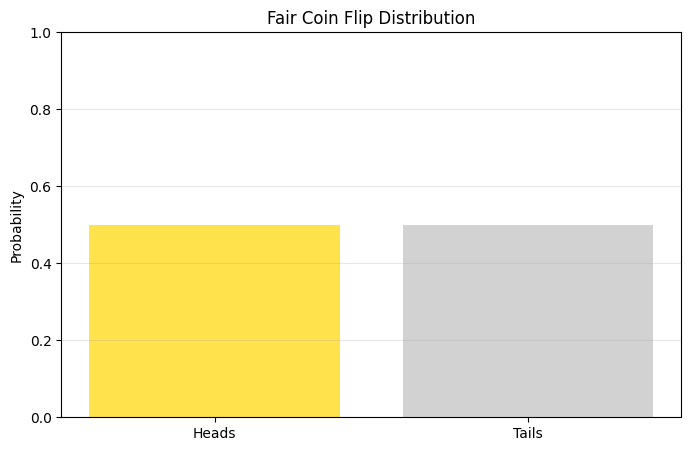

Sum of probabilities: 1.0


In [3]:
# Coin flip outcomes
outcomes = ['Heads', 'Tails']
probabilities = [0.5, 0.5]

# Visualize
plt.figure(figsize=(8, 5))
plt.bar(outcomes, probabilities, color=['gold', 'silver'], alpha=0.7)
plt.ylabel('Probability')
plt.title('Fair Coin Flip Distribution')
plt.ylim(0, 1)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

print(f"Sum of probabilities: {sum(probabilities)}")

**Key insight:** All probabilities must sum to 1 (one of the outcomes must occur).

## 3. Discrete vs Continuous Distributions

### Discrete Distributions

**Discrete distributions** describe outcomes that can be counted (integers, categories). Examples:
- Number of heads in 10 coin flips: {0, 1, 2, ..., 10}
- Die roll: {1, 2, 3, 4, 5, 6}
- Class labels: {"cat", "dog", "bird"}

We use a **PMF (Probability Mass Function)** to describe discrete distributions:
$$P(X = x)$$ gives the probability that random variable $X$ equals exactly $x$.

### Continuous Distributions

**Continuous distributions** describe outcomes that can take any value in a range (real numbers). Examples:
- Height: any value between 0 and 3 meters
- Temperature: any real number
- Time: any non-negative real number

We use a **PDF (Probability Density Function)** to describe continuous distributions. Important: $P(X = x) = 0$ for any specific value! Instead, we compute probabilities over ranges:
$$P(a \leq X \leq b) = \int_a^b f(x) dx$$

Let's visualize this critical difference.

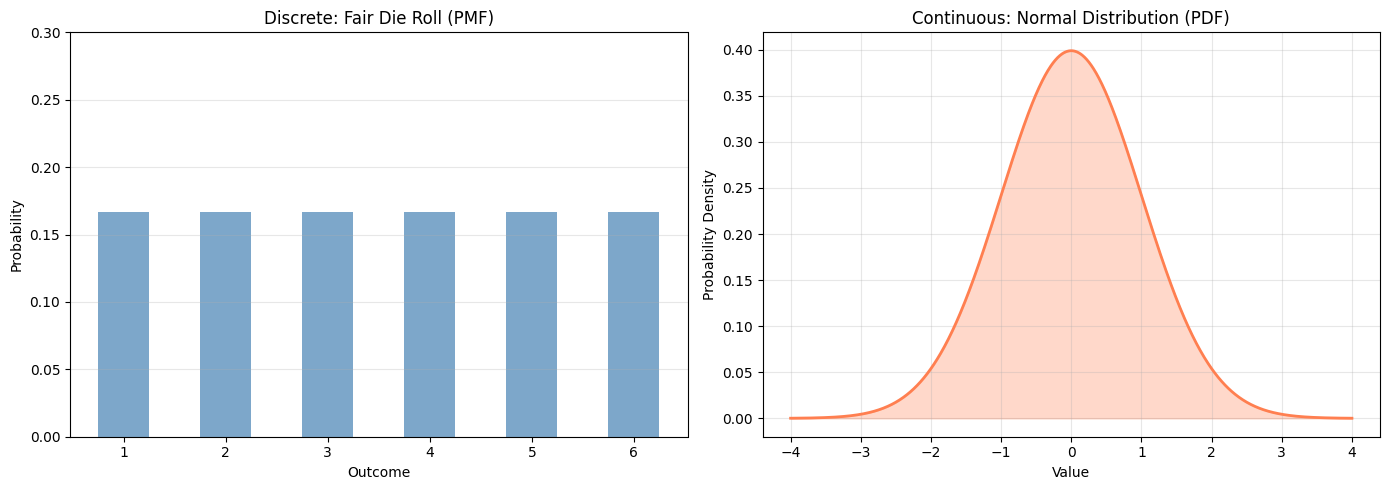

Discrete: Each bar shows P(X = x)
Continuous: Curve shows density; probability is the area under the curve


In [4]:
# Create a comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Discrete: Die roll
die_outcomes = [1, 2, 3, 4, 5, 6]
die_probs = [1/6] * 6
ax1.bar(die_outcomes, die_probs, color='steelblue', alpha=0.7, width=0.5)
ax1.set_xlabel('Outcome')
ax1.set_ylabel('Probability')
ax1.set_title('Discrete: Fair Die Roll (PMF)')
ax1.set_ylim(0, 0.3)
ax1.grid(True, alpha=0.3, axis='y')

# Continuous: Normal distribution
x = np.linspace(-4, 4, 1000)
pdf = stats.norm.pdf(x, loc=0, scale=1)
ax2.plot(x, pdf, color='coral', linewidth=2)
ax2.fill_between(x, pdf, alpha=0.3, color='coral')
ax2.set_xlabel('Value')
ax2.set_ylabel('Probability Density')
ax2.set_title('Continuous: Normal Distribution (PDF)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Discrete: Each bar shows P(X = x)")
print("Continuous: Curve shows density; probability is the area under the curve")

**Key difference:** For discrete, heights are probabilities. For continuous, the area under the curve represents probability.

## 4. Discrete Distributions

### 4.1 Bernoulli Distribution

The **Bernoulli distribution** models a single binary event (success/failure, yes/no, 1/0).

**Parameter:** $p$ = probability of success

**PMF:**
$$P(X = 1) = p$$
$$P(X = 0) = 1 - p$$

**Examples:** Coin flip, single email being spam/not spam, patient having disease/not having disease.

Let's create and visualize Bernoulli distributions with different values of $p$.

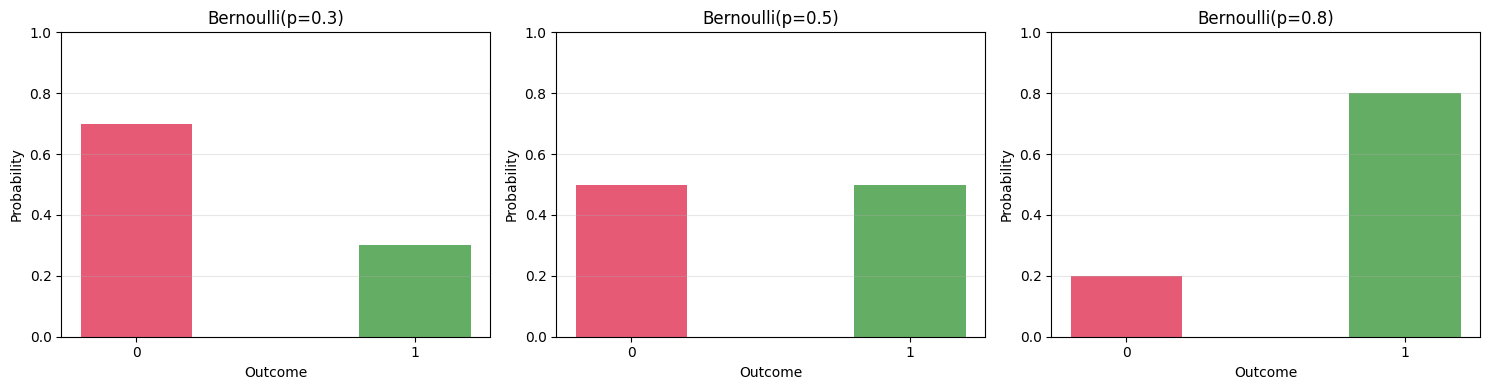

Notice: As p increases, success (1) becomes more likely than failure (0)


In [5]:
# Three different Bernoulli distributions
p_values = [0.3, 0.5, 0.8]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, p in enumerate(p_values):
    outcomes = [0, 1]
    probs = [1-p, p]
    
    axes[i].bar(outcomes, probs, color=['crimson', 'forestgreen'], alpha=0.7, width=0.4)
    axes[i].set_xlabel('Outcome')
    axes[i].set_ylabel('Probability')
    axes[i].set_title(f'Bernoulli(p={p})')
    axes[i].set_ylim(0, 1)
    axes[i].set_xticks([0, 1])
    axes[i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Notice: As p increases, success (1) becomes more likely than failure (0)")

Now let's sample from a Bernoulli distribution and see the empirical frequencies.

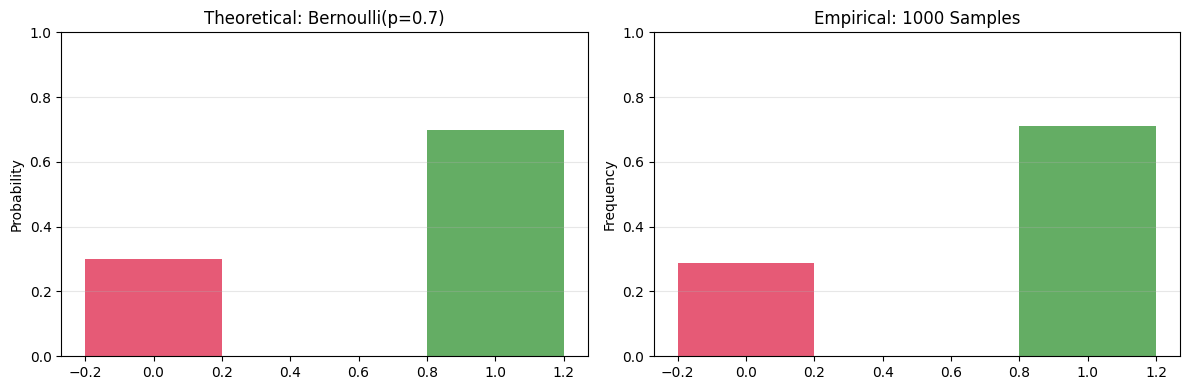

Theoretical P(X=1): 0.700
Empirical P(X=1): 0.712

With more samples, empirical approaches theoretical (Law of Large Numbers)


In [6]:
# Sample from Bernoulli(p=0.7)
p = 0.7
n_samples = 1000

samples = np.random.binomial(n=1, p=p, size=n_samples)

# Count frequencies
unique, counts = np.unique(samples, return_counts=True)
frequencies = counts / n_samples

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Theoretical
ax1.bar([0, 1], [1-p, p], color=['crimson', 'forestgreen'], alpha=0.7, width=0.4)
ax1.set_title('Theoretical: Bernoulli(p=0.7)')
ax1.set_ylabel('Probability')
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3, axis='y')

# Empirical
ax2.bar(unique, frequencies, color=['crimson', 'forestgreen'], alpha=0.7, width=0.4)
ax2.set_title(f'Empirical: {n_samples} Samples')
ax2.set_ylabel('Frequency')
ax2.set_ylim(0, 1)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Theoretical P(X=1): {p:.3f}")
print(f"Empirical P(X=1): {frequencies[1]:.3f}")
print(f"\nWith more samples, empirical approaches theoretical (Law of Large Numbers)")

**Key insight:** As we sample more, the empirical distribution converges to the theoretical distribution.

### 4.2 Categorical Distribution

The **Categorical distribution** generalizes Bernoulli to more than two outcomes.

**Parameters:** $\mathbf{p} = [p_1, p_2, ..., p_k]$ where $\sum_{i=1}^{k} p_i = 1$

**PMF:** $P(X = i) = p_i$

**Examples:** Die roll, image classification (cat/dog/bird), next word prediction in language models.

Let's model a classification problem with 5 classes.

Sum of probabilities: 1.0



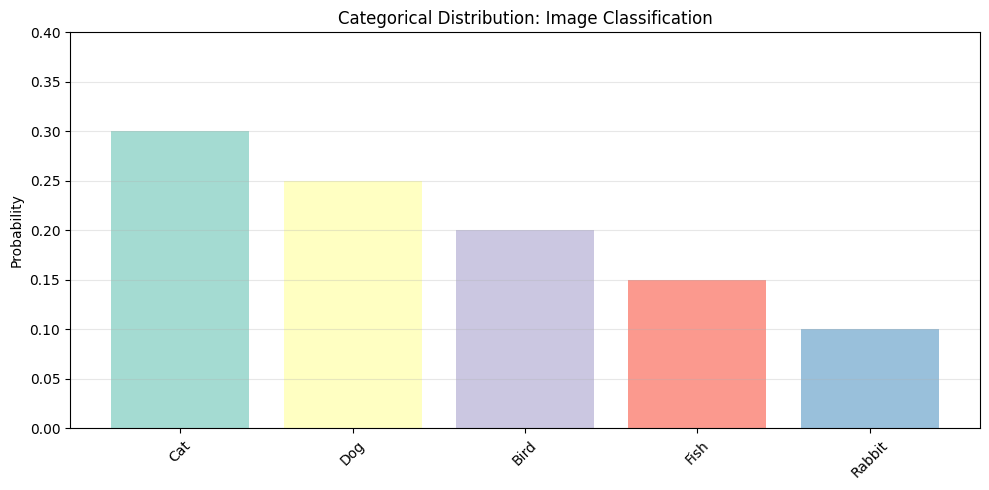

This could represent a neural network's output probabilities for an image.


In [7]:
# Image classification: 5 classes
classes = ['Cat', 'Dog', 'Bird', 'Fish', 'Rabbit']
probabilities = [0.3, 0.25, 0.2, 0.15, 0.1]

# Verify they sum to 1
print(f"Sum of probabilities: {sum(probabilities)}\n")

# Visualize
plt.figure(figsize=(10, 5))
colors = plt.cm.Set3(range(len(classes)))
plt.bar(classes, probabilities, color=colors, alpha=0.8)
plt.ylabel('Probability')
plt.title('Categorical Distribution: Image Classification')
plt.ylim(0, 0.4)
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("This could represent a neural network's output probabilities for an image.")

Sample from this categorical distribution to simulate predictions.

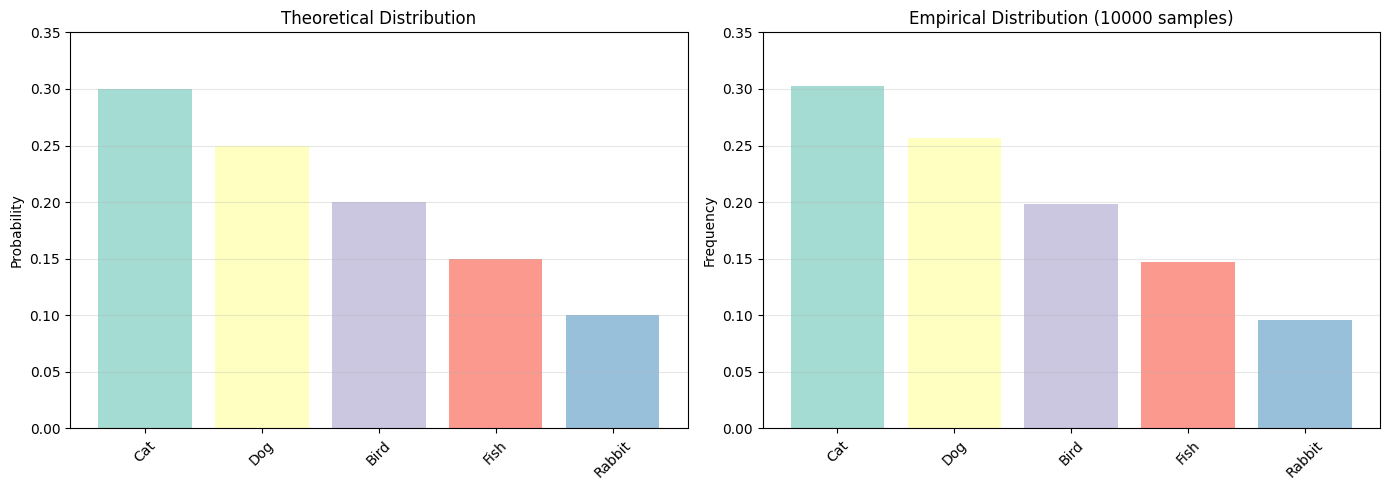

Theoretical vs Empirical:
Cat      - Theory: 0.300, Empirical: 0.303
Dog      - Theory: 0.250, Empirical: 0.256
Bird     - Theory: 0.200, Empirical: 0.198
Fish     - Theory: 0.150, Empirical: 0.147
Rabbit   - Theory: 0.100, Empirical: 0.096


In [8]:
# Sample 10000 predictions
n_samples = 10000
samples = np.random.choice(len(classes), size=n_samples, p=probabilities)

# Count frequencies
unique, counts = np.unique(samples, return_counts=True)
empirical_probs = counts / n_samples

# Compare theoretical vs empirical
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Theoretical
ax1.bar(classes, probabilities, color=colors, alpha=0.8)
ax1.set_ylabel('Probability')
ax1.set_title('Theoretical Distribution')
ax1.set_ylim(0, 0.35)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# Empirical
empirical_classes = [classes[i] for i in unique]
ax2.bar(empirical_classes, empirical_probs, color=colors, alpha=0.8)
ax2.set_ylabel('Frequency')
ax2.set_title(f'Empirical Distribution ({n_samples} samples)')
ax2.set_ylim(0, 0.35)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Print comparison
print("Theoretical vs Empirical:")
for i, cls in enumerate(classes):
    print(f"{cls:8} - Theory: {probabilities[i]:.3f}, Empirical: {empirical_probs[i]:.3f}")

**ML Connection:** Neural network classifiers output categorical distributions via the **softmax function**.

### 4.3 Binomial Distribution

The **Binomial distribution** counts the number of successes in $n$ independent Bernoulli trials.

**Parameters:**
- $n$ = number of trials
- $p$ = probability of success in each trial

**PMF:**
$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

**Example:** Number of heads in 10 coin flips.

Let's flip a coin 10 times and see the distribution of possible outcomes.

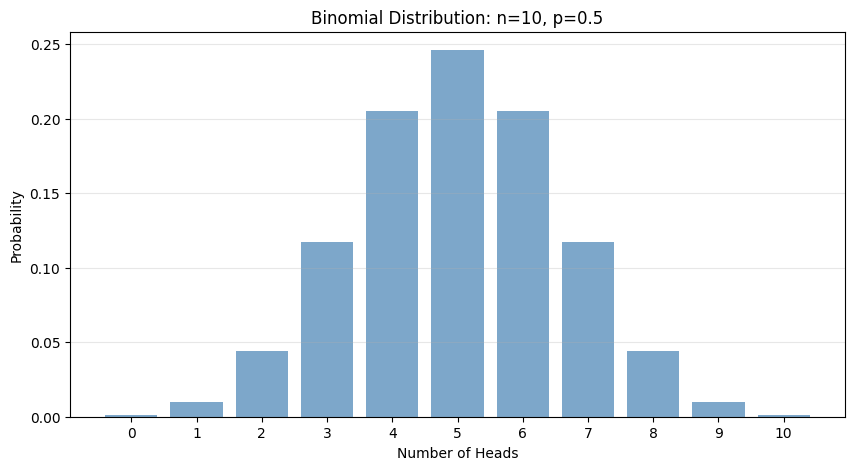

Most likely outcome: 5 heads
P(exactly 5 heads) = 0.2461
P(at least 7 heads) = 0.1719


In [9]:
# Binomial: 10 coin flips
n = 10  # number of flips
p = 0.5  # fair coin

# Calculate PMF
k_values = np.arange(0, n+1)
pmf = stats.binom.pmf(k_values, n, p)

# Visualize
plt.figure(figsize=(10, 5))
plt.bar(k_values, pmf, color='steelblue', alpha=0.7)
plt.xlabel('Number of Heads')
plt.ylabel('Probability')
plt.title(f'Binomial Distribution: n={n}, p={p}')
plt.xticks(k_values)
plt.grid(True, alpha=0.3, axis='y')
plt.show()

print(f"Most likely outcome: {k_values[np.argmax(pmf)]} heads")
print(f"P(exactly 5 heads) = {pmf[5]:.4f}")
print(f"P(at least 7 heads) = {sum(pmf[7:]):.4f}")

Now let's see how the distribution changes with different values of $p$ (biased coins).

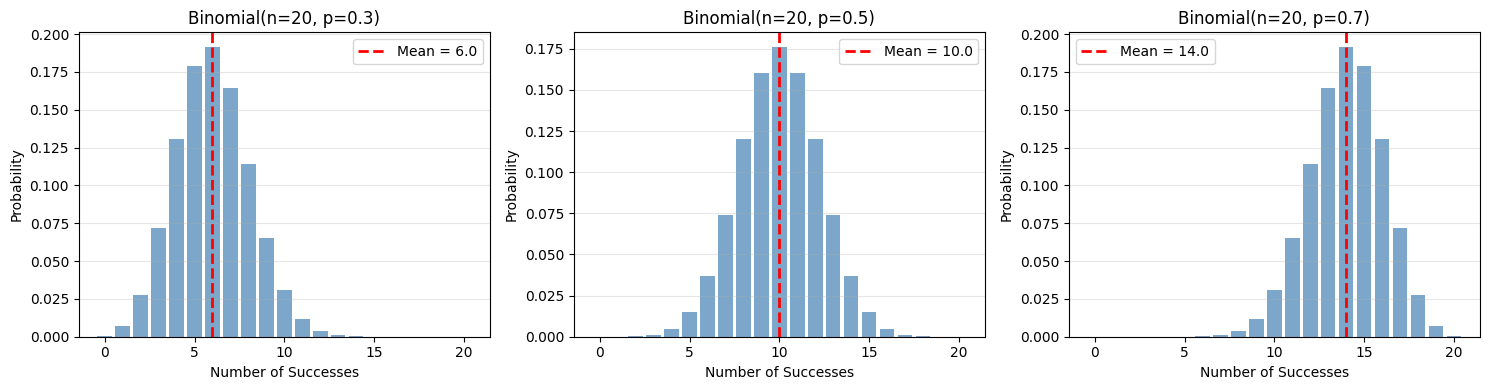

Notice: The distribution shifts right as p increases (more successes expected).


In [10]:
# Compare binomial distributions with different p values
n = 20
p_values = [0.3, 0.5, 0.7]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
k_values = np.arange(0, n+1)

for i, p in enumerate(p_values):
    pmf = stats.binom.pmf(k_values, n, p)
    axes[i].bar(k_values, pmf, color='steelblue', alpha=0.7)
    axes[i].set_xlabel('Number of Successes')
    axes[i].set_ylabel('Probability')
    axes[i].set_title(f'Binomial(n={n}, p={p})')
    axes[i].axvline(n*p, color='red', linestyle='--', linewidth=2, label=f'Mean = {n*p}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Notice: The distribution shifts right as p increases (more successes expected).")

**Key insight:** The mean (expected value) of Binomial$(n, p)$ is $np$, shown by the red dashed line.

## 5. Continuous Distributions

### 5.1 Uniform Distribution

The **Uniform distribution** assigns equal probability density to all values in a range $[a, b]$.

**Parameters:** $a$ (minimum), $b$ (maximum)

**PDF:**
$$f(x) = \begin{cases} 
\frac{1}{b-a} & \text{if } a \leq x \leq b \\
0 & \text{otherwise}
\end{cases}$$

**Example:** Random number generators, initializing neural network weights.

Let's visualize the uniform distribution.

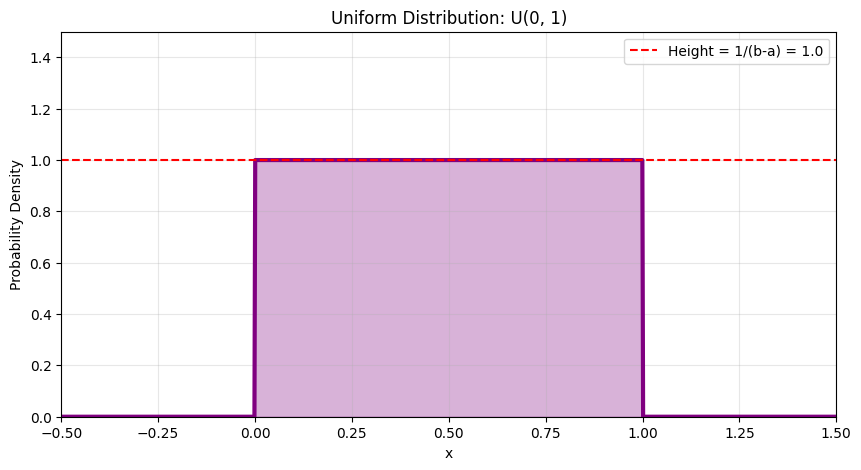

Total area under curve: 1.0 (must equal 1)
P(0.2 ≤ X ≤ 0.5) = 0.3 (length of interval)


In [11]:
# Uniform distribution on [0, 1]
a, b = 0, 1
x = np.linspace(-0.5, 1.5, 1000)
pdf = stats.uniform.pdf(x, loc=a, scale=b-a)

plt.figure(figsize=(10, 5))
plt.plot(x, pdf, linewidth=3, color='purple')
plt.fill_between(x, pdf, alpha=0.3, color='purple')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title(f'Uniform Distribution: U({a}, {b})')
plt.xlim(-0.5, 1.5)
plt.ylim(0, 1.5)
plt.grid(True, alpha=0.3)
plt.axhline(y=1/(b-a), color='red', linestyle='--', label=f'Height = 1/(b-a) = {1/(b-a)}')
plt.legend()
plt.show()

print(f"Total area under curve: {(b-a) * (1/(b-a))} (must equal 1)")
print(f"P(0.2 ≤ X ≤ 0.5) = {0.5 - 0.2} (length of interval)")

Sample from the uniform distribution and visualize the histogram.

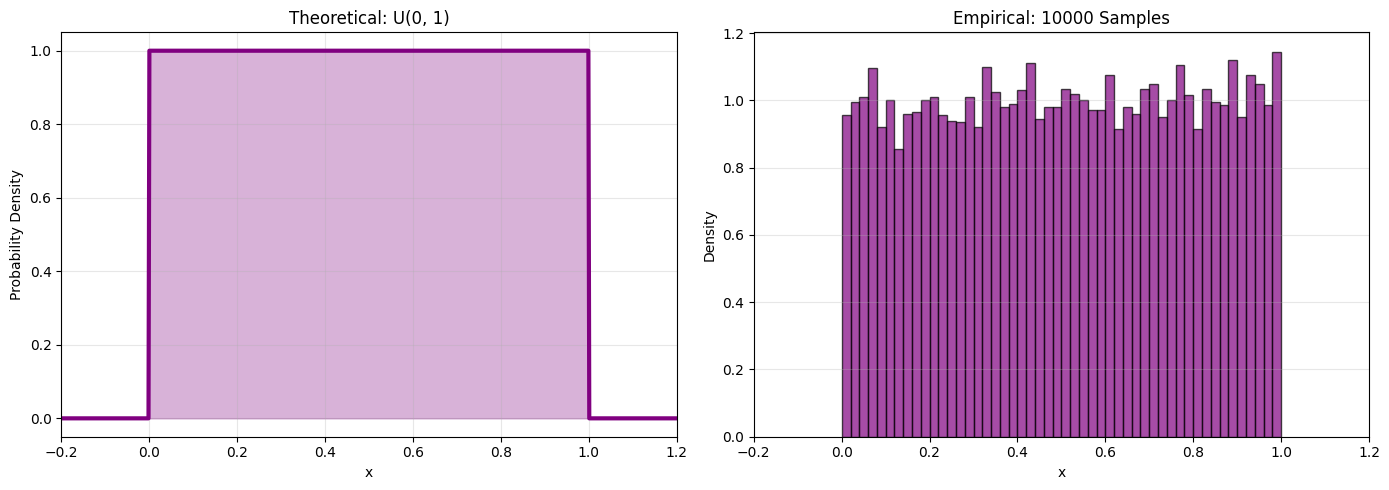

Sample mean: 0.5054 (theoretical: 0.5)
Sample variance: 0.0838 (theoretical: 0.0833)


In [12]:
# Sample from U(0, 1)
n_samples = 10000
samples = np.random.uniform(a, b, n_samples)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Theoretical PDF
ax1.plot(x, pdf, linewidth=3, color='purple')
ax1.fill_between(x, pdf, alpha=0.3, color='purple')
ax1.set_xlabel('x')
ax1.set_ylabel('Probability Density')
ax1.set_title('Theoretical: U(0, 1)')
ax1.set_xlim(-0.2, 1.2)
ax1.grid(True, alpha=0.3)

# Empirical histogram
ax2.hist(samples, bins=50, density=True, alpha=0.7, color='purple', edgecolor='black')
ax2.set_xlabel('x')
ax2.set_ylabel('Density')
ax2.set_title(f'Empirical: {n_samples} Samples')
ax2.set_xlim(-0.2, 1.2)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"Sample mean: {np.mean(samples):.4f} (theoretical: {(a+b)/2})")
print(f"Sample variance: {np.var(samples):.4f} (theoretical: {((b-a)**2)/12:.4f})")

**Key insight:** With continuous distributions, we use histograms to approximate the density from samples.

### 5.2 Gaussian (Normal) Distribution ⭐

The **Gaussian** (or **Normal**) distribution is the most important distribution in statistics and ML.

**Parameters:**
- $\mu$ = mean (center of the distribution)
- $\sigma^2$ = variance (spread/width)

**PDF:**
$$f(x) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$

**Why it matters:**
- Many natural phenomena follow normal distributions (heights, test scores, measurement errors)
- Central Limit Theorem: sum of many random variables → normal
- VAEs model data as samples from Gaussian distributions
- Gaussian noise is added during training (dropout variants, data augmentation)

Let's visualize the standard normal distribution $\mathcal{N}(0, 1)$.

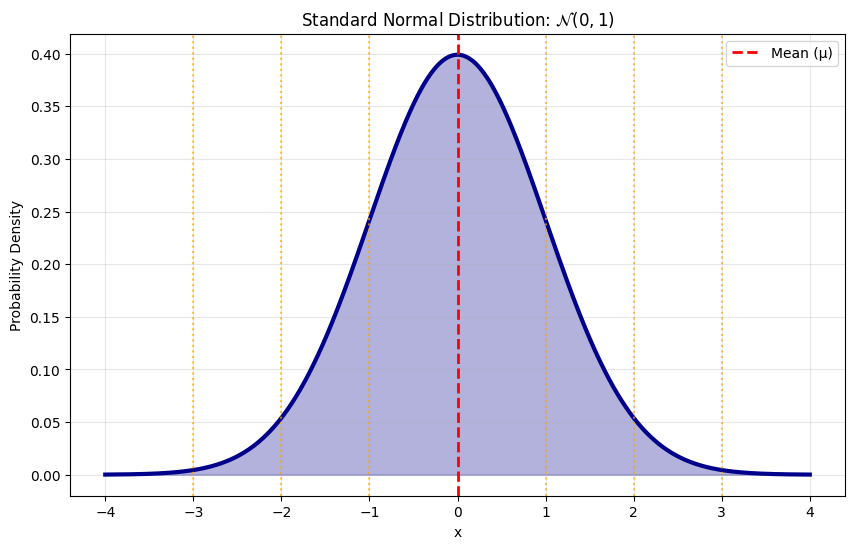

68-95-99.7 Rule:
  P(μ-σ ≤ X ≤ μ+σ) ≈ 68% (within 1 std dev)
  P(μ-2σ ≤ X ≤ μ+2σ) ≈ 95% (within 2 std devs)
  P(μ-3σ ≤ X ≤ μ+3σ) ≈ 99.7% (within 3 std devs)


In [13]:
# Standard normal: N(0, 1)
mu, sigma = 0, 1
x = np.linspace(-4, 4, 1000)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

plt.figure(figsize=(10, 6))
plt.plot(x, pdf, linewidth=3, color='darkblue')
plt.fill_between(x, pdf, alpha=0.3, color='darkblue')

# Mark mean and standard deviations
plt.axvline(mu, color='red', linestyle='--', linewidth=2, label='Mean (μ)')
for i in range(1, 4):
    plt.axvline(mu + i*sigma, color='orange', linestyle=':', alpha=0.7, linewidth=1.5)
    plt.axvline(mu - i*sigma, color='orange', linestyle=':', alpha=0.7, linewidth=1.5)

plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title(r'Standard Normal Distribution: $\mathcal{N}(0, 1)$')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("68-95-99.7 Rule:")
print(f"  P(μ-σ ≤ X ≤ μ+σ) ≈ 68% (within 1 std dev)")
print(f"  P(μ-2σ ≤ X ≤ μ+2σ) ≈ 95% (within 2 std devs)")
print(f"  P(μ-3σ ≤ X ≤ μ+3σ) ≈ 99.7% (within 3 std devs)")

Now let's see how changing $\mu$ and $\sigma$ affects the distribution.

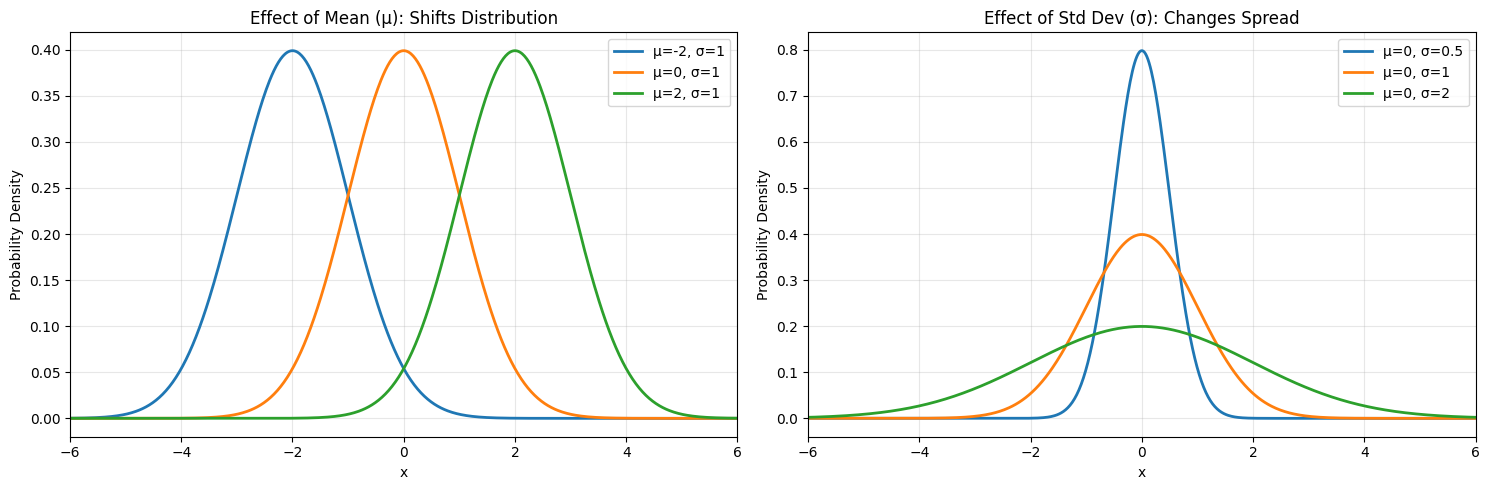

Mean (μ): Controls the center/location
Std Dev (σ): Controls the width/spread (smaller σ = more concentrated)


In [14]:
# Effect of changing parameters
x = np.linspace(-10, 10, 1000)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Effect of mean (μ)
means = [-2, 0, 2]
sigma = 1
for mu in means:
    pdf = stats.norm.pdf(x, loc=mu, scale=sigma)
    ax1.plot(x, pdf, linewidth=2, label=f'μ={mu}, σ={sigma}')
ax1.set_xlabel('x')
ax1.set_ylabel('Probability Density')
ax1.set_title('Effect of Mean (μ): Shifts Distribution')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(-6, 6)

# Effect of standard deviation (σ)
mu = 0
sigmas = [0.5, 1, 2]
for sigma in sigmas:
    pdf = stats.norm.pdf(x, loc=mu, scale=sigma)
    ax2.plot(x, pdf, linewidth=2, label=f'μ={mu}, σ={sigma}')
ax2.set_xlabel('x')
ax2.set_ylabel('Probability Density')
ax2.set_title('Effect of Std Dev (σ): Changes Spread')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(-6, 6)

plt.tight_layout()
plt.show()

print("Mean (μ): Controls the center/location")
print("Std Dev (σ): Controls the width/spread (smaller σ = more concentrated)")

Let's sample from a Gaussian and verify the statistics.

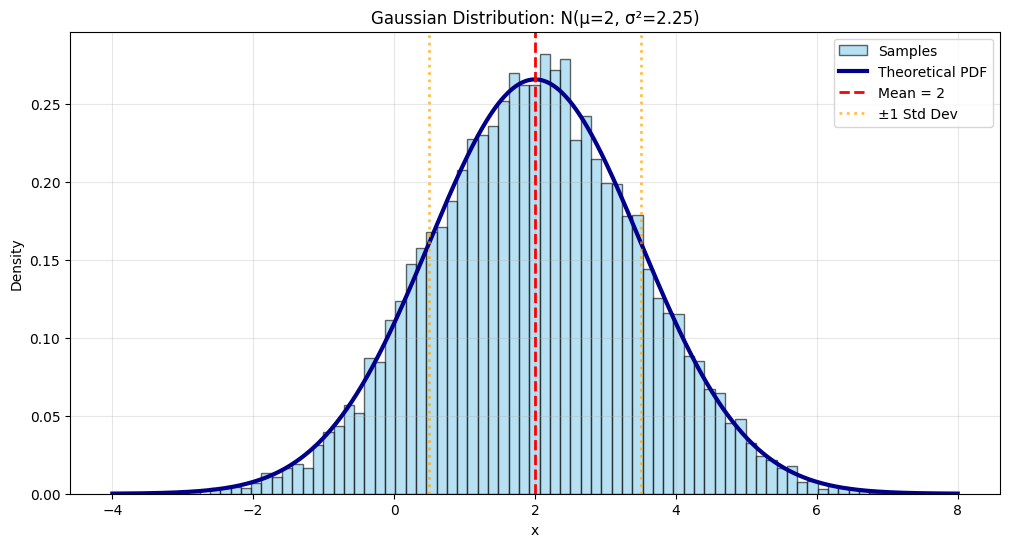

Theoretical - Mean: 2, Variance: 2.25
Empirical   - Mean: 2.0068, Variance: 2.2001


In [15]:
# Sample from N(2, 1.5^2)
mu, sigma = 2, 1.5
n_samples = 10000
samples = np.random.normal(mu, sigma, n_samples)

# Theoretical PDF
x = np.linspace(-4, 8, 1000)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)

# Visualize
plt.figure(figsize=(12, 6))
plt.hist(samples, bins=80, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Samples')
plt.plot(x, pdf, linewidth=3, color='darkblue', label='Theoretical PDF')
plt.axvline(mu, color='red', linestyle='--', linewidth=2, label=f'Mean = {mu}')
plt.axvline(mu-sigma, color='orange', linestyle=':', linewidth=2, alpha=0.7)
plt.axvline(mu+sigma, color='orange', linestyle=':', linewidth=2, alpha=0.7, label=f'±1 Std Dev')
plt.xlabel('x')
plt.ylabel('Density')
plt.title(f'Gaussian Distribution: N(μ={mu}, σ²={sigma**2})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Theoretical - Mean: {mu}, Variance: {sigma**2}")
print(f"Empirical   - Mean: {np.mean(samples):.4f}, Variance: {np.var(samples):.4f}")

**Key insight:** The empirical (sampled) statistics match the theoretical parameters as sample size increases.

## 6. Mean and Variance: Summary Statistics

### Expected Value (Mean)

The **expected value** $E[X]$ or **mean** $\mu$ represents the "center" of a distribution.

**Discrete:**
$$E[X] = \sum_{x} x \cdot P(X = x)$$

**Continuous:**
$$E[X] = \int_{-\infty}^{\infty} x \cdot f(x) dx$$

**Intuition:** The weighted average of all possible values.

### Variance

The **variance** $\text{Var}(X)$ or $\sigma^2$ measures the "spread" of a distribution.

$$\text{Var}(X) = E[(X - \mu)^2] = E[X^2] - (E[X])^2$$

**Standard deviation** $\sigma = \sqrt{\text{Var}(X)}$ has the same units as $X$.

**Intuition:** Average squared distance from the mean.

Let's compute these for different distributions.

In [16]:
# Summary statistics for various distributions
distributions = [
    ('Bernoulli(0.7)', stats.bernoulli(0.7)),
    ('Binomial(20, 0.5)', stats.binom(20, 0.5)),
    ('Uniform(0, 1)', stats.uniform(0, 1)),
    ('Normal(0, 1)', stats.norm(0, 1)),
]

print("Distribution Summary Statistics:")
print("=" * 60)
print(f"{'Distribution':<25} {'Mean':<12} {'Variance':<12}")
print("=" * 60)

for name, dist in distributions:
    mean = dist.mean()
    var = dist.var()
    print(f"{name:<25} {mean:<12.4f} {var:<12.4f}")

print("=" * 60)

Distribution Summary Statistics:
Distribution              Mean         Variance    
Bernoulli(0.7)            0.7000       0.2100      
Binomial(20, 0.5)         10.0000      5.0000      
Uniform(0, 1)             0.5000       0.0833      
Normal(0, 1)              0.0000       1.0000      


Visualize how variance affects distribution shape for Gaussians.

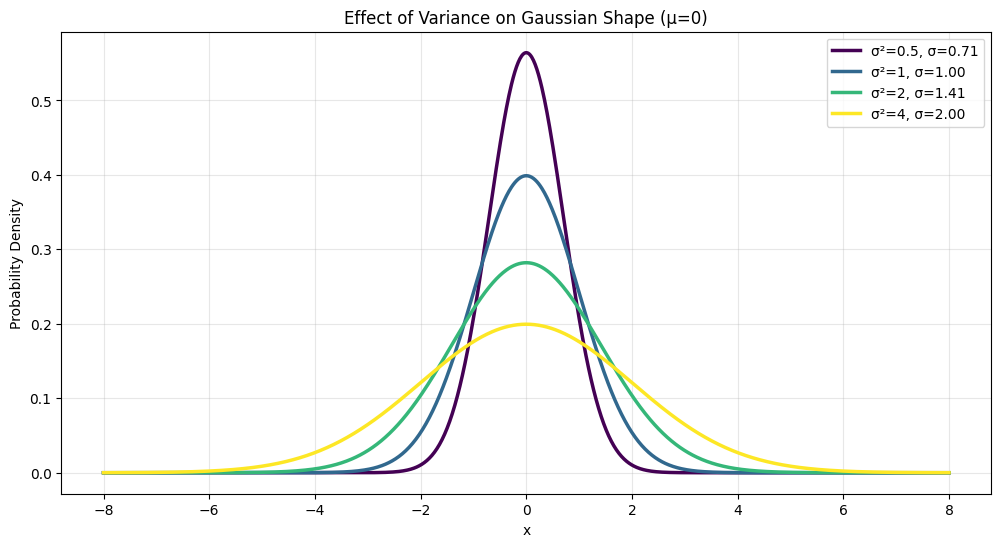

Higher variance → wider, flatter distribution
Lower variance → narrower, taller distribution
Total area under each curve = 1 (probability axiom)


In [17]:
# Same mean, different variances
mu = 0
variances = [0.5, 1, 2, 4]
x = np.linspace(-8, 8, 1000)

plt.figure(figsize=(12, 6))
colors = plt.cm.viridis(np.linspace(0, 1, len(variances)))

for var, color in zip(variances, colors):
    sigma = np.sqrt(var)
    pdf = stats.norm.pdf(x, loc=mu, scale=sigma)
    plt.plot(x, pdf, linewidth=2.5, label=f'σ²={var}, σ={sigma:.2f}', color=color)

plt.xlabel('x')
plt.ylabel('Probability Density')
plt.title('Effect of Variance on Gaussian Shape (μ=0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Higher variance → wider, flatter distribution")
print("Lower variance → narrower, taller distribution")
print("Total area under each curve = 1 (probability axiom)")

## 7. The Central Limit Theorem

### Why Gaussians Are Everywhere

The **Central Limit Theorem (CLT)** states that the sum (or average) of many independent random variables approaches a Gaussian distribution, regardless of the original distribution.

This explains why:
- Heights are normally distributed (sum of genetic + environmental factors)
- Measurement errors are Gaussian (sum of many small random errors)
- Neural network activations often become Gaussian (sum of many inputs)

Let's demonstrate CLT by summing uniform random variables.

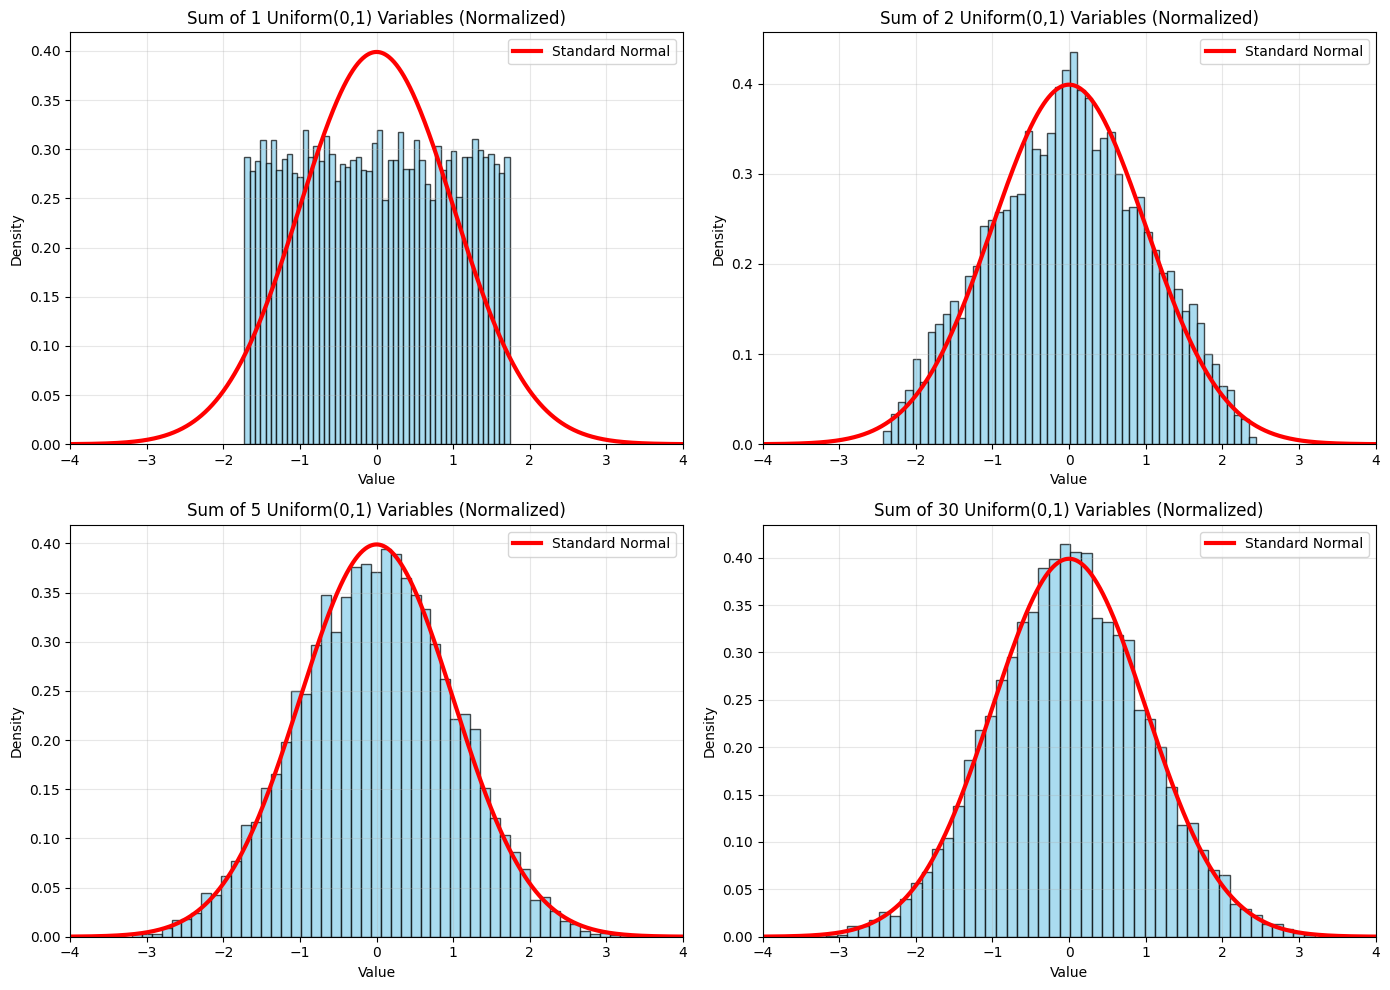

Central Limit Theorem in action:
As n increases, the sum converges to a Gaussian distribution!
This works even though we started with uniform (non-Gaussian) variables.


In [18]:
# Start with uniform distribution U(0, 1)
n_samples = 10000
n_sums = [1, 2, 5, 30]  # Sum this many uniform variables

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, n in enumerate(n_sums):
    # Sum n uniform random variables
    sums = np.zeros(n_samples)
    for _ in range(n):
        sums += np.random.uniform(0, 1, n_samples)
    
    # Normalize to see the shape more clearly
    sums_normalized = (sums - np.mean(sums)) / np.std(sums)
    
    # Plot histogram
    axes[i].hist(sums_normalized, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
    
    # Overlay theoretical normal
    x = np.linspace(-4, 4, 1000)
    pdf = stats.norm.pdf(x, 0, 1)
    axes[i].plot(x, pdf, 'r-', linewidth=3, label='Standard Normal')
    
    axes[i].set_title(f'Sum of {n} Uniform(0,1) Variables (Normalized)')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)
    axes[i].set_xlim(-4, 4)

plt.tight_layout()
plt.show()

print("Central Limit Theorem in action:")
print("As n increases, the sum converges to a Gaussian distribution!")
print("This works even though we started with uniform (non-Gaussian) variables.")

**Key insight:** The CLT is why Gaussians appear everywhere in nature and ML!

## 8. Connections to Machine Learning

### 8.1 Cross-Entropy Loss

**Cross-entropy loss** measures how well predicted probabilities match true labels.

For classification with $K$ classes:
$$\text{CrossEntropy} = -\sum_{i=1}^{K} y_i \log(\hat{y}_i)$$

where $y$ is the true distribution (one-hot) and $\hat{y}$ is the predicted distribution (from softmax).

**This is directly based on categorical distributions!**

Let's compute cross-entropy for different predictions.

Cross-Entropy Loss for Different Predictions:
True label: Cat

Confident & Correct       Predicted: [0.9  0.05 0.05]  Loss: 0.1054
Uncertain                 Predicted: [0.4 0.3 0.3]  Loss: 0.9163
Confident & Wrong         Predicted: [0.05 0.9  0.05]  Loss: 2.9957

Lower loss = better match to true distribution
Confident wrong predictions are heavily penalized!


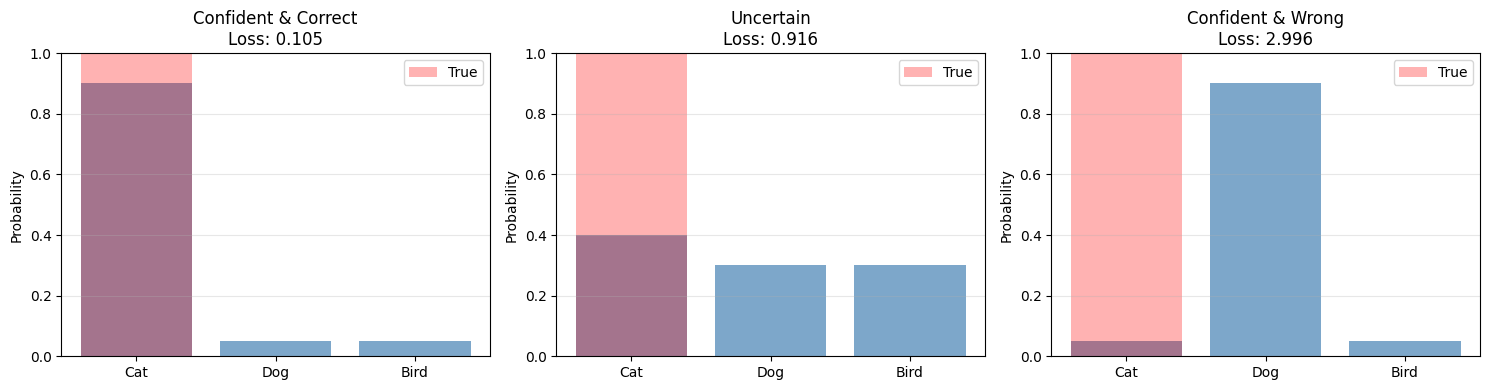

In [19]:
# True label: class 1 (Cat)
classes = ['Cat', 'Dog', 'Bird']
true_label = np.array([1, 0, 0])  # One-hot: Cat

# Three different predictions
predictions = [
    ('Confident & Correct', np.array([0.9, 0.05, 0.05])),
    ('Uncertain', np.array([0.4, 0.3, 0.3])),
    ('Confident & Wrong', np.array([0.05, 0.9, 0.05])),
]

print("Cross-Entropy Loss for Different Predictions:")
print("=" * 70)
print(f"True label: Cat\n")

losses = []
for name, pred in predictions:
    # Cross-entropy: -sum(y * log(y_hat))
    ce_loss = -np.sum(true_label * np.log(pred + 1e-9))  # Add small epsilon to avoid log(0)
    losses.append(ce_loss)
    print(f"{name:<25} Predicted: {pred}  Loss: {ce_loss:.4f}")

print("=" * 70)
print("\nLower loss = better match to true distribution")
print("Confident wrong predictions are heavily penalized!")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, (name, pred) in enumerate(predictions):
    axes[i].bar(classes, pred, color='steelblue', alpha=0.7)
    axes[i].bar(classes, true_label, color='red', alpha=0.3, label='True')
    axes[i].set_ylabel('Probability')
    axes[i].set_title(f'{name}\nLoss: {losses[i]:.3f}')
    axes[i].set_ylim(0, 1)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

**ML Connection:** Neural networks output categorical distributions, and we use cross-entropy to train them.

### 8.2 Variational Autoencoders (VAEs)

**VAEs** learn to represent data as samples from a Gaussian distribution in latent space.

Key idea:
1. Encoder maps input $x$ to Gaussian parameters $(\mu, \sigma)$
2. Sample $z \sim \mathcal{N}(\mu, \sigma^2)$ from the distribution
3. Decoder reconstructs $x$ from $z$

**Loss function includes KL divergence** between learned distribution and prior $\mathcal{N}(0, 1)$.

Let's simulate the VAE sampling process.

Encoder outputs: μ=2.0, log(σ²)=0.5
This defines a Gaussian: N(2.0, 1.649)



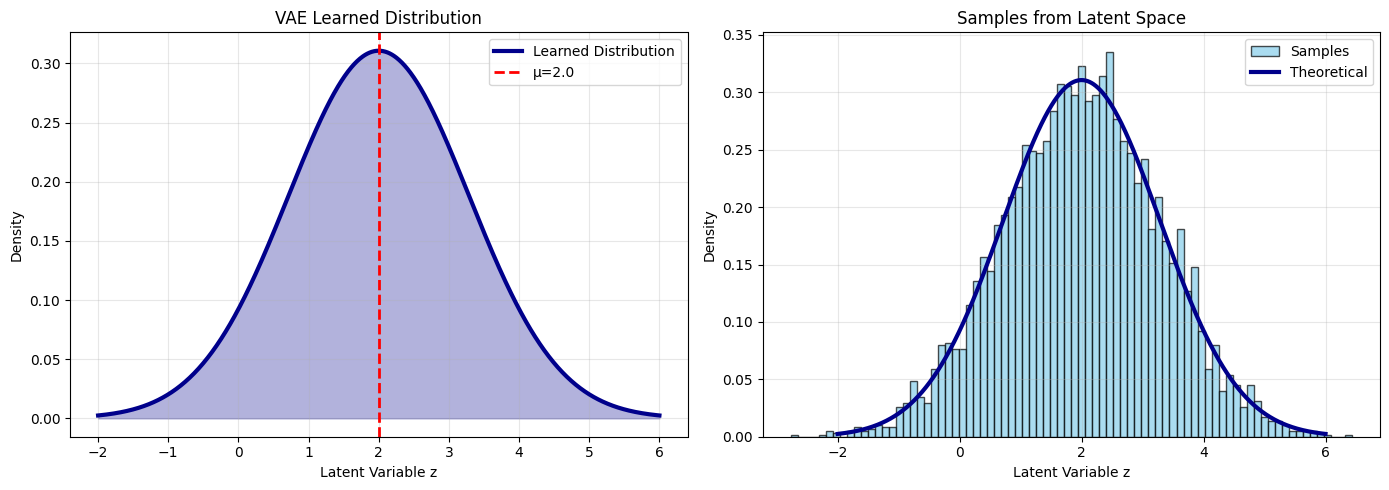

These samples would be passed to the decoder to reconstruct the input.
By sampling, VAEs can generate new data by sampling from learned distributions!


In [20]:
# Simulate VAE encoding
# Encoder outputs mean and log-variance for stability
mu = 2.0
log_var = 0.5
sigma = np.exp(0.5 * log_var)  # Convert log-variance to std dev

print(f"Encoder outputs: μ={mu}, log(σ²)={log_var}")
print(f"This defines a Gaussian: N({mu}, {sigma**2:.3f})\n")

# Sample from this distribution (reparameterization trick)
n_samples = 5000
epsilon = np.random.normal(0, 1, n_samples)  # Sample from N(0,1)
z = mu + sigma * epsilon  # Reparameterization: z = μ + σ * ε

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Theoretical distribution
x = np.linspace(-2, 6, 1000)
pdf = stats.norm.pdf(x, loc=mu, scale=sigma)
ax1.plot(x, pdf, linewidth=3, color='darkblue', label='Learned Distribution')
ax1.fill_between(x, pdf, alpha=0.3, color='darkblue')
ax1.axvline(mu, color='red', linestyle='--', linewidth=2, label=f'μ={mu}')
ax1.set_xlabel('Latent Variable z')
ax1.set_ylabel('Density')
ax1.set_title('VAE Learned Distribution')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Samples
ax2.hist(z, bins=80, density=True, alpha=0.7, color='skyblue', edgecolor='black', label='Samples')
ax2.plot(x, pdf, linewidth=3, color='darkblue', label='Theoretical')
ax2.set_xlabel('Latent Variable z')
ax2.set_ylabel('Density')
ax2.set_title('Samples from Latent Space')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("These samples would be passed to the decoder to reconstruct the input.")
print("By sampling, VAEs can generate new data by sampling from learned distributions!")

**ML Connection:** Understanding Gaussians is essential for VAEs, which are powerful generative models!

### 8.3 Why Understanding Distributions Matters

Throughout your ML journey, you'll encounter distributions constantly:

**Loss Functions:**
- Cross-entropy: Based on categorical/Bernoulli distributions
- Mean Squared Error (MSE): Assumes Gaussian noise
- KL Divergence: Measures difference between distributions

**Model Outputs:**
- Classification: Categorical distribution (via softmax)
- Regression: Often assume Gaussian distribution around prediction
- Generative models: Model data distribution (VAEs, GANs, Diffusion)

**Training:**
- Weight initialization: Often from Gaussian or Uniform
- Dropout: Bernoulli distribution for masking
- Data augmentation: Sample from noise distributions

**Reinforcement Learning:**
- Policy: Distribution over actions (categorical for discrete, Gaussian for continuous)
- Value estimation: Distributions over returns

**You now have the foundation to understand all of these!**

## 9. Interactive Exploration

Let's create an interactive comparison of all the distributions we've learned.

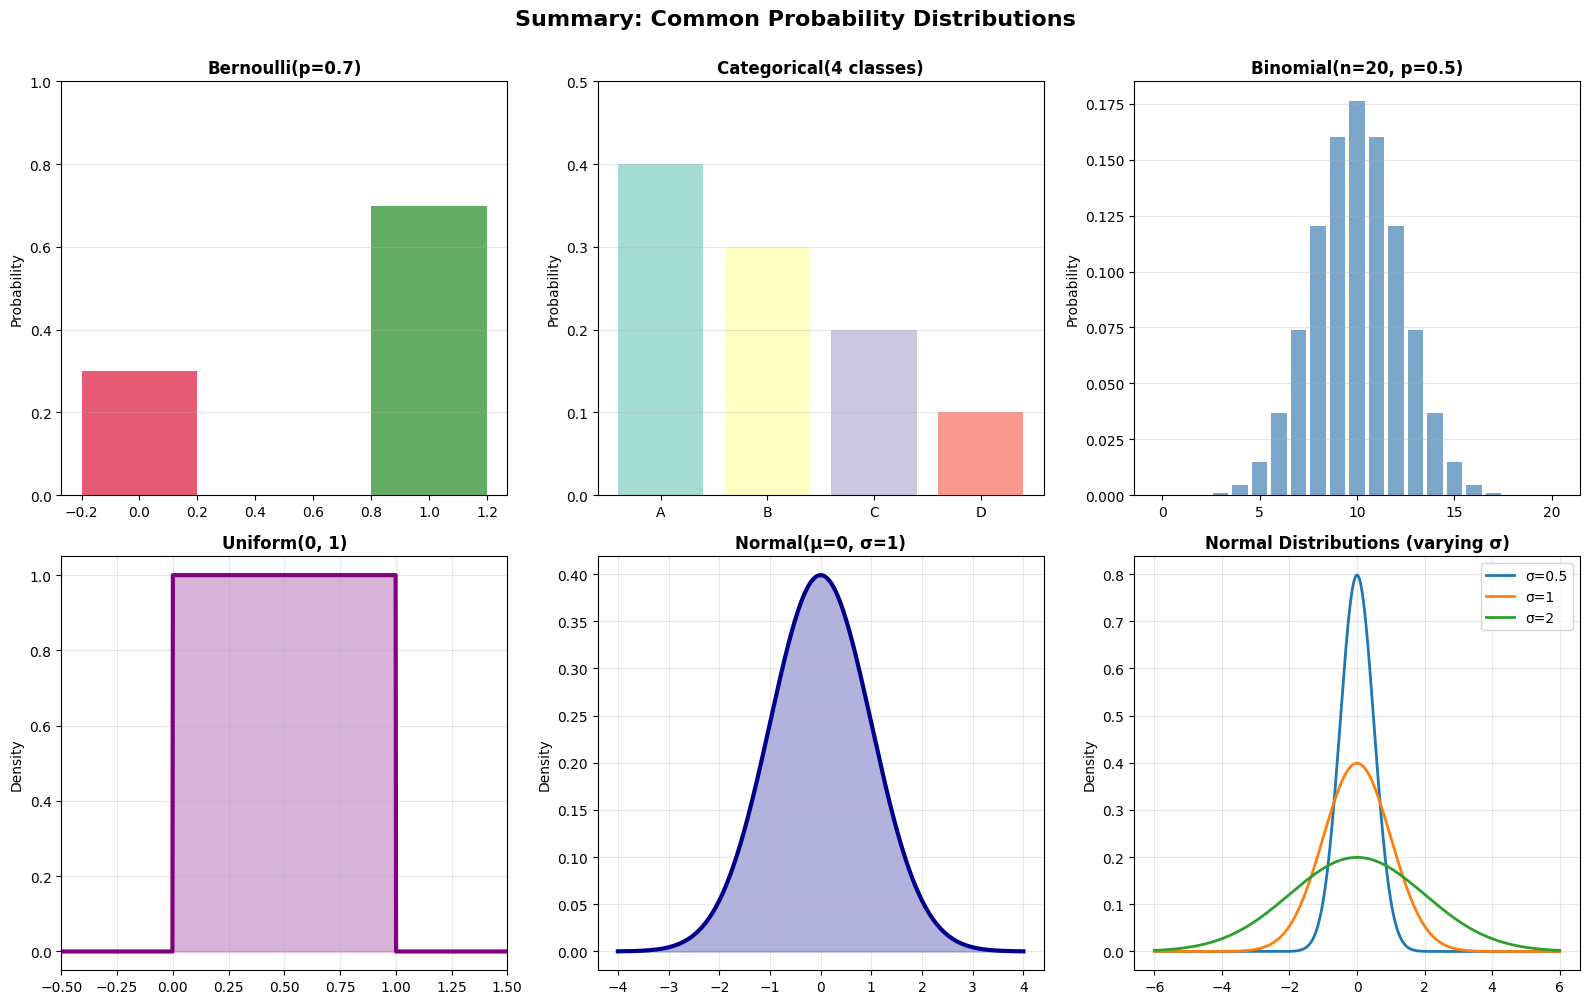

You now know the fundamental probability distributions used throughout ML!


In [21]:
# Compare multiple distributions side by side
fig = plt.figure(figsize=(16, 10))

# Discrete distributions
# 1. Bernoulli
ax1 = plt.subplot(2, 3, 1)
p = 0.7
ax1.bar([0, 1], [1-p, p], color=['crimson', 'forestgreen'], alpha=0.7, width=0.4)
ax1.set_title(f'Bernoulli(p={p})', fontsize=12, fontweight='bold')
ax1.set_ylabel('Probability')
ax1.set_ylim(0, 1)
ax1.grid(True, alpha=0.3, axis='y')

# 2. Categorical
ax2 = plt.subplot(2, 3, 2)
classes = ['A', 'B', 'C', 'D']
probs = [0.4, 0.3, 0.2, 0.1]
ax2.bar(classes, probs, color=plt.cm.Set3(range(4)), alpha=0.8)
ax2.set_title('Categorical(4 classes)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Probability')
ax2.set_ylim(0, 0.5)
ax2.grid(True, alpha=0.3, axis='y')

# 3. Binomial
ax3 = plt.subplot(2, 3, 3)
n, p = 20, 0.5
k = np.arange(0, n+1)
pmf = stats.binom.pmf(k, n, p)
ax3.bar(k, pmf, color='steelblue', alpha=0.7)
ax3.set_title(f'Binomial(n={n}, p={p})', fontsize=12, fontweight='bold')
ax3.set_ylabel('Probability')
ax3.grid(True, alpha=0.3, axis='y')

# Continuous distributions
# 4. Uniform
ax4 = plt.subplot(2, 3, 4)
x = np.linspace(-0.5, 1.5, 1000)
pdf = stats.uniform.pdf(x, 0, 1)
ax4.plot(x, pdf, linewidth=3, color='purple')
ax4.fill_between(x, pdf, alpha=0.3, color='purple')
ax4.set_title('Uniform(0, 1)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Density')
ax4.set_xlim(-0.5, 1.5)
ax4.grid(True, alpha=0.3)

# 5. Normal
ax5 = plt.subplot(2, 3, 5)
x = np.linspace(-4, 4, 1000)
pdf = stats.norm.pdf(x, 0, 1)
ax5.plot(x, pdf, linewidth=3, color='darkblue')
ax5.fill_between(x, pdf, alpha=0.3, color='darkblue')
ax5.set_title('Normal(μ=0, σ=1)', fontsize=12, fontweight='bold')
ax5.set_ylabel('Density')
ax5.grid(True, alpha=0.3)

# 6. Comparison of multiple normals
ax6 = plt.subplot(2, 3, 6)
x = np.linspace(-6, 6, 1000)
params = [(0, 0.5), (0, 1), (0, 2)]
for mu, sigma in params:
    pdf = stats.norm.pdf(x, mu, sigma)
    ax6.plot(x, pdf, linewidth=2, label=f'σ={sigma}')
ax6.set_title('Normal Distributions (varying σ)', fontsize=12, fontweight='bold')
ax6.set_ylabel('Density')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.suptitle('Summary: Common Probability Distributions', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("You now know the fundamental probability distributions used throughout ML!")

## 10. Key Takeaways

### Core Concepts

1. **Discrete vs Continuous:**
   - Discrete: Countable outcomes, use PMF, probabilities are bar heights
   - Continuous: Uncountable outcomes, use PDF, probabilities are areas under curve

2. **Key Distributions:**
   - **Bernoulli**: Single binary event (coin flip)
   - **Categorical**: Multiple discrete outcomes (classification)
   - **Binomial**: Number of successes in n trials (repeated coin flips)
   - **Uniform**: All values equally likely in a range (initialization)
   - **Gaussian/Normal**: Most important distribution (CLT, VAEs, everywhere!)

3. **Summary Statistics:**
   - **Mean (μ)**: Center/location of distribution
   - **Variance (σ²)**: Spread/width of distribution
   - **Standard Deviation (σ)**: Square root of variance, same units as data

4. **Central Limit Theorem:**
   - Sum of many random variables → Gaussian
   - Why Gaussians appear everywhere in nature and ML

5. **ML Connections:**
   - Cross-entropy loss: Based on categorical distributions
   - VAEs: Model data as samples from Gaussians
   - Weight initialization: Sample from Uniform or Gaussian
   - Neural network outputs: Categorical (softmax) or Gaussian distributions

### What's Next?

You now have the foundation to understand:
- **KL Divergence**: Measures how different two distributions are (critical for VAEs)
- **Maximum Likelihood Estimation**: Finding model parameters that maximize probability of data
- **Bayesian Inference**: Updating beliefs using probability distributions
- **Generative Models**: VAEs, GANs, Diffusion models that learn data distributions

**Remember:** Every time you see loss functions, model outputs, or uncertainty in ML, probability distributions are at work behind the scenes. You now have the intuition to recognize and understand them!